In [9]:
import numpy as np
import json
import pickle
from pathlib import Path
from tensorflow.keras.models import load_model
from xgboost import XGBClassifier

In [10]:
## loading the models for classification
autoendcoder=load_model("../models/autoencoder.keras")

baseline=XGBClassifier(); baseline.load_model("../models/xgboost_122_baseline.json")
hybrid124=XGBClassifier(); hybrid124.load_model("../models/xgboost_124_hybrid.json")
hybrid125=XGBClassifier(); hybrid125.load_model("../models/xgboost_125_final.json")
custom_hybrid=XGBClassifier(); custom_hybrid.load_model("../models/custom_weights/xgboost_cost_final.json")

In [12]:
X_train_122 = np.load("../data/processed/X_train.npy")
X_test_122  = np.load( "../data/processed/X_test.npy")
y_train     = np.load("../data/processed/y_train.npy")
y_test      = np.load("../data/processed/y_test.npy")

content_train = np.load("../data/processed/recon_error_content_train.npy").reshape(-1, 1)
content_test  = np.load("../data/processed/recon_error_content_test.npy").reshape(-1, 1)
other_train   = np.load("../data/processed/recon_error_other_train.npy").reshape(-1, 1)
other_test    = np.load("../data/processed/recon_error_other_test.npy").reshape(-1, 1)
behav_train   = np.load("../data/preprocessed/behavioral_gaussian_score_train.npy").reshape(-1, 1)
behav_test    = np.load("../data/preprocessed/behavioral_gaussian_score_test.npy").reshape(-1, 1)

X_train_124 = np.hstack([X_train_122, content_train, other_train])
X_test_124  = np.hstack([X_test_122,  content_test,  other_test])

X_train_125 = np.hstack([X_train_124, behav_train])
X_test_125  = np.hstack([X_test_124,  behav_test])

In [14]:
models = {
    "Baseline (122)":              (baseline,      X_test_122),
    "Hybrid (124)":                (hybrid124,        X_test_124),
    "Hybrid (125, balanced)":      (hybrid125,        X_test_125),
    "Hybrid (125, custom weights)": (custom_hybrid, X_test_125),
}

print("\nLoaded models:", list(models.keys()))


Loaded models: ['Baseline (122)', 'Hybrid (124)', 'Hybrid (125, balanced)', 'Hybrid (125, custom weights)']


In [15]:
from sklearn.metrics import f1_score, classification_report

class_names = ["Normal", "DoS", "Probe", "R2L", "U2R"]

results = []
predictions = {}  # store y_pred per model, needed later for confusion matrices

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    predictions[name] = y_pred

    macro_f1 = f1_score(y_test, y_pred, average="macro")
    per_class_f1 = f1_score(y_test, y_pred, average=None, labels=[0, 1, 2, 3, 4])

    row = {"model": name, "macro_f1": macro_f1}
    row.update({cls: f1 for cls, f1 in zip(class_names, per_class_f1)})
    results.append(row)

import pandas as pd
results_df = pd.DataFrame(results).set_index("model")
results_df

,macro_f1,Normal,DoS,Probe,R2L,U2R
model,,,,,,
Baseline (122),0.604262,0.819014,0.914034,0.769532,0.163175,0.355556
Hybrid (124),0.635545,0.831494,0.909273,0.833333,0.224678,0.378947
"Hybrid (125, balanced)",0.640707,0.827596,0.904364,0.843407,0.240414,0.387755
"Hybrid (125, custom weights)",0.641766,0.826682,0.902147,0.841343,0.266107,0.372549


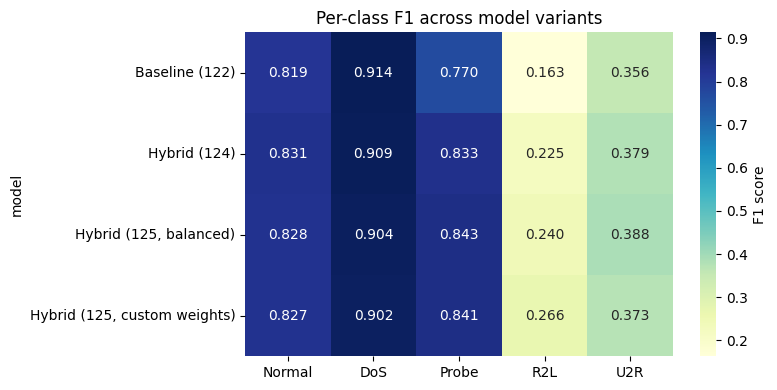

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    results_df[class_names],
    annot=True, fmt=".3f", cmap="YlGnBu",
    cbar_kws={"label": "F1 score"},
    ax=ax
)
ax.set_title("Per-class F1 across model variants")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

def bootstrap_macro_f1_ci(y_true, y_pred, n_resamples=5000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boot_f1s = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        boot_f1s[i] = f1_score(y_true[idx], y_pred[idx], average="macro")
    lower, upper = np.percentile(boot_f1s, [2.5, 97.5])
    return lower, upper

ci_data = []
for name in models:
    y_pred = predictions[name]
    point = results_df.loc[name, "macro_f1"]
    lower, upper = bootstrap_macro_f1_ci(y_test, y_pred)
    ci_data.append({"model": name, "point": point, "lower": lower, "upper": upper})

ci_df = pd.DataFrame(ci_data).set_index("model")
ci_df

,point,lower,upper
model,,,
Baseline (122),0.604262,0.576670,0.629844
Hybrid (124),0.635545,0.608530,0.660342
"Hybrid (125, balanced)",0.640707,0.614138,0.665303
"Hybrid (125, custom weights)",0.641766,0.615751,0.666408


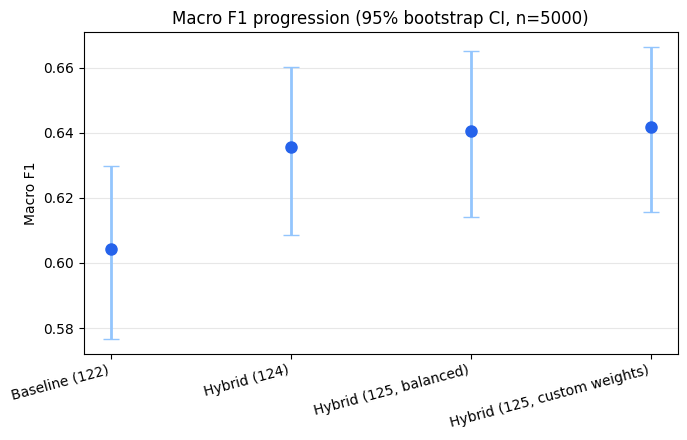

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(ci_df))
yerr = [ci_df["point"] - ci_df["lower"], ci_df["upper"] - ci_df["point"]]

ax.errorbar(x, ci_df["point"], yerr=yerr, fmt="o", markersize=8,
            capsize=6, color="#2563eb", ecolor="#93c5fd", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(ci_df.index, rotation=15, ha="right")
ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 progression (95% bootstrap CI, n=5000)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

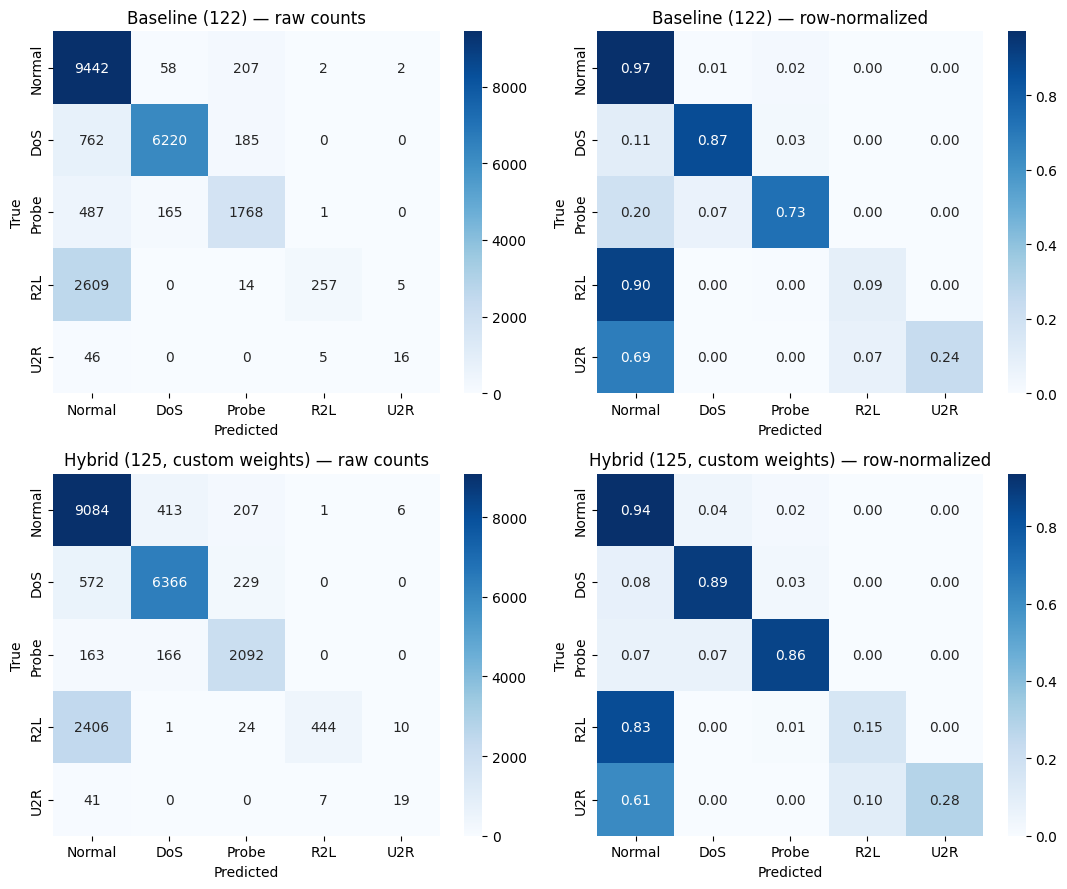

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

compare_models = ["Baseline (122)", "Hybrid (125, custom weights)"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for row, name in enumerate(compare_models):
    cm = confusion_matrix(y_test, predictions[name], labels=[0, 1, 2, 3, 4])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[row, 0])
    axes[row, 0].set_title(f"{name} — raw counts")
    axes[row, 0].set_ylabel("True")
    axes[row, 0].set_xlabel("Predicted")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[row, 1])
    axes[row, 1].set_title(f"{name} — row-normalized")
    axes[row, 1].set_ylabel("True")
    axes[row, 1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

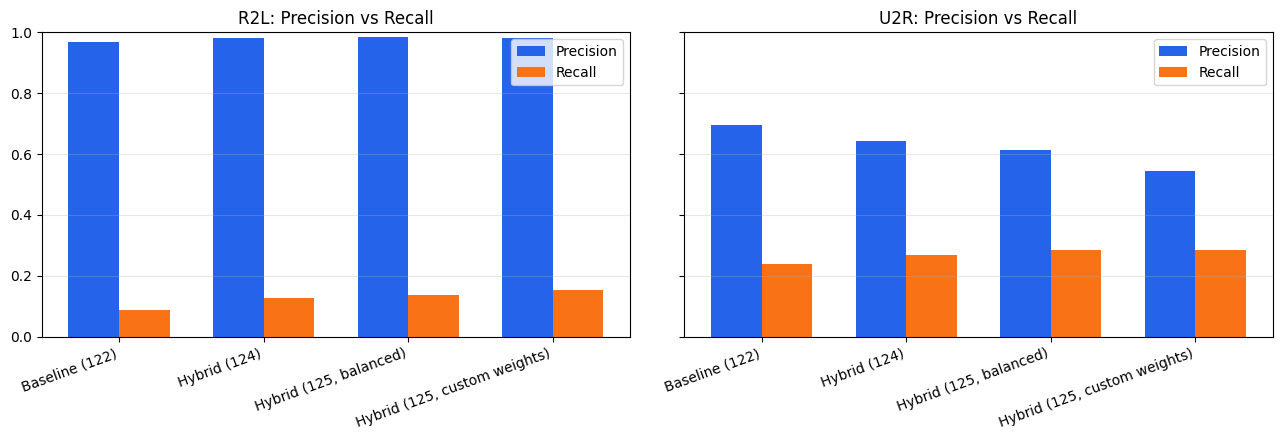

In [20]:
from sklearn.metrics import precision_score, recall_score

pr_rows = []
for name in models:
    y_pred = predictions[name]
    prec = precision_score(y_test, y_pred, average=None, labels=[0,1,2,3,4], zero_division=0)
    rec  = recall_score(y_test, y_pred, average=None, labels=[0,1,2,3,4], zero_division=0)
    for cls, p, r in zip(class_names, prec, rec):
        pr_rows.append({"model": name, "class": cls, "precision": p, "recall": r})

pr_df = pd.DataFrame(pr_rows)

# focus on R2L and U2R — this is where the precision-vs-recall story matters most
focus = pr_df[pr_df["class"].isin(["R2L", "U2R"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, cls in zip(axes, ["R2L", "U2R"]):
    sub = focus[focus["class"] == cls]
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width/2, sub["precision"], width, label="Precision", color="#2563eb")
    ax.bar(x + width/2, sub["recall"], width, label="Recall", color="#f97316")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model"], rotation=20, ha="right")
    ax.set_title(f"{cls}: Precision vs Recall")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

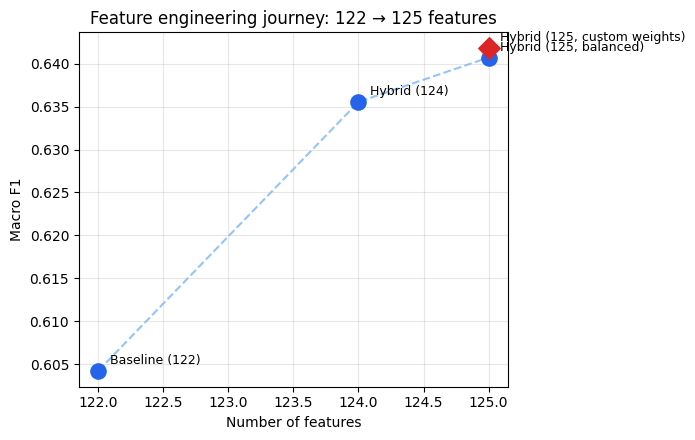

In [22]:
feature_counts = {
    "Baseline (122)": 122,
    "Hybrid (124)": 124,
    "Hybrid (125, balanced)": 125,
    "Hybrid (125, custom weights)": 125,  # same feature count, different weights — mark distinctly
}

journey_df = results_df.copy()
journey_df["n_features"] = journey_df.index.map(feature_counts)

fig, ax = plt.subplots(figsize=(7, 4.5))

# separate the two 125-feature points slightly so they don't overlap visually
for name, row in journey_df.iterrows():
    marker = "o" if "custom" not in name else "D"
    color = "#2563eb" if "custom" not in name else "#dc2626"
    ax.scatter(row["n_features"], row["macro_f1"], s=120, color=color, marker=marker, zorder=3)
    ax.annotate(name, (row["n_features"], row["macro_f1"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# connect the balanced-weight progression line only (122->124->125)
line_order = ["Baseline (122)", "Hybrid (124)", "Hybrid (125, balanced)"]
ax.plot(journey_df.loc[line_order, "n_features"], journey_df.loc[line_order, "macro_f1"],
        color="#93c5fd", linestyle="--", zorder=1)

ax.set_xlabel("Number of features")
ax.set_ylabel("Macro F1")
ax.set_title("Feature engineering journey: 122 → 125 features")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
def catch_set(y_true, y_pred, target_class, mask_indices):
    """Returns boolean array: True where model correctly predicted target_class."""
    return (y_pred[mask_indices] == target_class)

model_a, model_b = "Baseline (122)", "Hybrid (125, custom weights)"

for target_class, cls_name in [(3, "R2L"), (4, "U2R")]:
    idx = np.where(y_test == target_class)[0]
    correct_a = catch_set(y_test, predictions[model_a], target_class, idx)
    correct_b = catch_set(y_test, predictions[model_b], target_class, idx)

    both        = np.sum(correct_a & correct_b)
    only_a      = np.sum(correct_a & ~correct_b)   # baseline caught, hybrid missed (regression)
    only_b      = np.sum(~correct_a & correct_b)   # hybrid caught, baseline missed (the win)
    neither     = np.sum(~correct_a & ~correct_b)

    print(f"\n{cls_name} (n={len(idx)}):")
    print(f"  Both correct:            {both}")
    print(f"  Only {model_a} correct:  {only_a}  <- regression, worth checking")
    print(f"  Only {model_b} correct:  {only_b}  <- the hybrid win")
    print(f"  Neither correct:         {neither}")


R2L (n=2885):
  Both correct:            253
  Only Baseline (122) correct:  4  <- regression, worth checking
  Only Hybrid (125, custom weights) correct:  191  <- the hybrid win
  Neither correct:         2437

U2R (n=67):
  Both correct:            15
  Only Baseline (122) correct:  1  <- regression, worth checking
  Only Hybrid (125, custom weights) correct:  4  <- the hybrid win
  Neither correct:         47


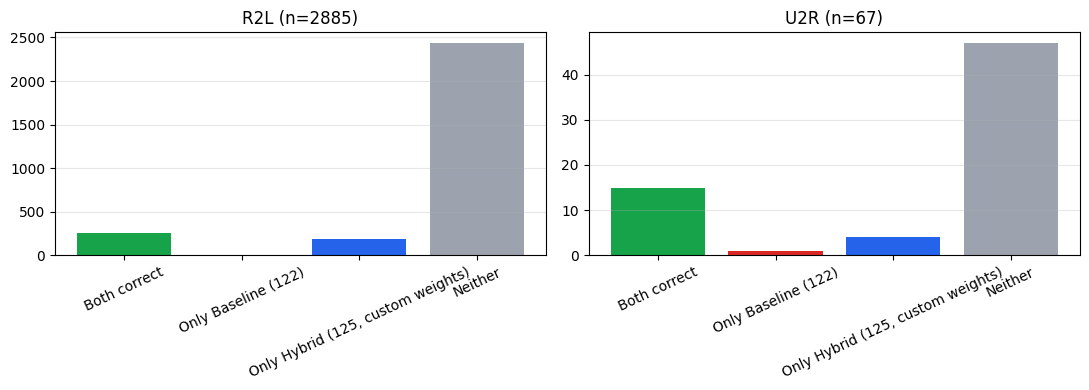

In [24]:
# venn-style bar visual for the same numbers
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ["Both correct", f"Only {model_a}", f"Only {model_b}", "Neither"]

for ax, (target_class, cls_name) in zip(axes, [(3, "R2L"), (4, "U2R")]):
    idx = np.where(y_test == target_class)[0]
    correct_a = catch_set(y_test, predictions[model_a], target_class, idx)
    correct_b = catch_set(y_test, predictions[model_b], target_class, idx)
    counts = [
        np.sum(correct_a & correct_b),
        np.sum(correct_a & ~correct_b),
        np.sum(~correct_a & correct_b),
        np.sum(~correct_a & ~correct_b),
    ]
    ax.bar(labels, counts, color=["#16a34a", "#dc2626", "#2563eb", "#9ca3af"])
    ax.set_title(f"{cls_name} (n={len(idx)})")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()